# Minimum maturity calibration for product-store series

The purpose of $(W,k)$ is to define when a product-store series has enough local history to be considered **mature** for fair forecast evaluation:

- $W$ is the number of observed/open days available before the local forecast origin.
- $k$ is the minimum number of positive-demand days among those $W$ observations.
- The candidate grid is `W = [31, 61, 91, 121, 151, 181]` and `k = [10, 15, 20, 25, 30]`.
- Each candidate is tested on the next seven calendar days using three deliberately simple baselines.

> $(W,k)$ is calibrated on FCM because FCM is the limiting source group. Pseudo is validated separately in `02_02_first_origin.ipynb` using only history available before the first common forecast origin.

The selected pair must preserve broad FCM series, product, store, and future-demand coverage while keeping the three baseline forecasts within declared WAPE and bias limits. Demand-class agreement is not used: weak agreement is evidence that ADI-CV2 class stability should not be a hard maturity-selection criterion.

In [1]:
from pathlib import Path
from io import BytesIO
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import duckdb
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display, Image

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid", context="notebook")

GROUP_COLS = ["ARTIKEL_ID", "MARKT_ID"]
DEMAND_COL = "ABVERKAUFTE_MENGE_KG"
CALIBRATION_GROUP = "FCM"
WINDOW_CANDIDATES = [31, 61, 91, 121, 151, 181]
MIN_DEMAND_CANDIDATES = [10, 15, 20, 25, 30]
FORECAST_HORIZON_DAYS = 7

# Baseline definitions. Their short windows keep the test focused on maturity,
# rather than allowing a complex model to compensate for inadequate history.
RECENT_MEAN_DAYS = 28
SAME_WEEKDAY_OCCURRENCES = 4
POSITIVE_QUANTITY_OBSERVATIONS = 10
BASELINE_COLUMNS = {
    "recent_mean": "Recent mean (28 observations)",
    "same_weekday_moving_average": "Same-weekday moving average (4 occurrences)",
    "occurrence_x_positive_quantity": "Occurrence x positive quantity",
}

# FCM selection gates, declared before the result surface is inspected.
MIN_FCM_SERIES_COVERAGE = 0.75
MIN_FCM_PRODUCT_COVERAGE = 0.75
MIN_FCM_STORE_COVERAGE = 0.75
MIN_FUTURE_DEMAND_RETENTION = 0.8
MAX_BASELINE_WAPE = 1.15
MAX_ABS_RELATIVE_BIAS = 0.15

PROJECT_ROOT = next(
    (p.resolve() for p in [Path("../.."), Path(".."), Path(".")] if (p / "src").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not find the project root containing src/.")

DATA_DIR = PROJECT_ROOT / "data/interim/transactions_dst_daily_min_demand_no_outliers"
parquet_files = sorted(DATA_DIR.glob("*.parquet"))
if not parquet_files:
    raise FileNotFoundError(f"No parquet files found in {DATA_DIR}")
DATA_GLOB = str(DATA_DIR / "*.parquet")

con = duckdb.connect()
con.execute("PRAGMA threads=4")

def display_figure(fig, dpi=120):
    figure_buffer = BytesIO()
    fig.savefig(figure_buffer, format="png", dpi=dpi, bbox_inches="tight")
    display(Image(data=figure_buffer.getvalue()))
    plt.close(fig)

## Data basis and audit

The unit is a daily `ARTIKEL_ID` x `MARKT_ID` row. A present row is an observed/open day; closed dates are not inserted. FCM takes precedence in the source assignment, and the audit stops on overlapping flags, duplicate series-dates, or source/category changes. Only reporting categories 890 and 900 are in scope.

In [2]:
con.execute(f"""
CREATE OR REPLACE TEMP TABLE daily_rows AS
SELECT
    ARTIKEL_ID,
    MARKT_ID,
    CAST(DATE AS DATE) AS period,
    CAST(COALESCE({DEMAND_COL}, 0) AS DOUBLE) AS demand,
    is_fcm,
    is_pseudo,
    WGR_ID::INTEGER AS category_id,
    CASE
        WHEN is_fcm THEN 'FCM'
        WHEN is_pseudo THEN 'Pseudo'
    END AS sourcing_group
FROM read_parquet('{DATA_GLOB}')
WHERE (is_fcm OR is_pseudo)
  AND WGR_ID IN (890, 900)
""")

row_audit = con.execute("""
SELECT
    COUNT(*) AS rows,
    MIN(period) AS first_date,
    MAX(period) AS last_date,
    COUNT_IF(is_fcm IS NULL) AS null_fcm_flags,
    COUNT_IF(is_pseudo IS NULL) AS null_pseudo_flags,
    COUNT_IF(is_fcm AND is_pseudo) AS overlapping_source_flags
FROM daily_rows
""").fetchdf()

duplicate_series_dates = con.execute("""
SELECT COUNT(*)
FROM (
    SELECT ARTIKEL_ID, MARKT_ID, period
    FROM daily_rows
    GROUP BY ALL
    HAVING COUNT(*) > 1
)
""").fetchone()[0]
changing_series_attributes = con.execute("""
SELECT COUNT(*)
FROM (
    SELECT ARTIKEL_ID, MARKT_ID
    FROM daily_rows
    GROUP BY ARTIKEL_ID, MARKT_ID
    HAVING COUNT(DISTINCT sourcing_group) > 1
        OR COUNT(DISTINCT category_id) > 1
)
""").fetchone()[0]
row_audit["duplicate_series_dates"] = duplicate_series_dates
row_audit["changing_series_attributes"] = changing_series_attributes
display(row_audit)

failure_columns = [
    "null_fcm_flags", "null_pseudo_flags", "overlapping_source_flags",
    "duplicate_series_dates", "changing_series_attributes",
]
if row_audit[failure_columns].sum(axis=1).iloc[0]:
    raise RuntimeError("Source/category audit failed; inspect row_audit.")

con.execute("""
CREATE OR REPLACE TEMP TABLE ordered_rows AS
SELECT
    *,
    ROW_NUMBER() OVER (
        PARTITION BY sourcing_group, ARTIKEL_ID, MARKT_ID
        ORDER BY period
    ) AS active_day_number,
    EXTRACT(DOW FROM period)::INTEGER AS weekday
FROM daily_rows
""")

population = con.execute("""
WITH series_stats AS (
    SELECT
        sourcing_group,
        ARTIKEL_ID,
        MARKT_ID,
        COUNT(*) AS active_days,
        SUM(demand) AS total_demand_kg
    FROM daily_rows
    GROUP BY ALL
)
SELECT
    sourcing_group,
    SUM(active_days) AS rows,
    COUNT(*) AS series,
    COUNT(DISTINCT ARTIKEL_ID) AS products,
    COUNT(DISTINCT MARKT_ID) AS stores,
    SUM(total_demand_kg) AS total_demand_kg,
    MEDIAN(active_days) AS median_active_days
FROM series_stats
GROUP BY sourcing_group
ORDER BY CASE sourcing_group WHEN 'FCM' THEN 1 ELSE 2 END
""").fetchdf()
display(population.style.format({
    "rows": "{:,.0f}", "series": "{:,.0f}", "products": "{:,.0f}",
    "stores": "{:,.0f}", "total_demand_kg": "{:,.1f}",
    "median_active_days": "{:,.1f}",
}))

,rows,first_date,last_date,null_fcm_flags,null_pseudo_flags,overlapping_source_flags,duplicate_series_dates,changing_series_attributes
0,19934887,2023-07-22,2026-07-21,0.0,0.0,0.0,0,0


,sourcing_group,rows,series,products,stores,total_demand_kg,median_active_days
0,FCM,"790,764","2,907",29,190,"151,014.8",303.0
1,Pseudo,"19,144,123","22,262",342,192,"20,160,335.1",906.0


## Candidate evaluation design

For each series and candidate $W$, its local maturity origin is the date of its $W$th observed/open day. Training uses only the first $W$ observations. Evaluation uses observed rows in the next seven calendar days; no closed-day zeroes are manufactured.

The three baselines are intentionally transparent:

1. **Recent mean:** mean demand over the latest 28 observed/open training days.
2. **Same-weekday moving average:** mean of up to four most recent training observations with the test row's weekday; the recent mean is the fallback.
3. **Occurrence x positive quantity:** positive-demand frequency over the latest 28 observations multiplied by the mean of up to the latest 10 positive quantities.

For a candidate $(W,k)$, an evaluable series is retained if at least $k$ of its first $W$ observations have positive demand. Series, product, and store coverage use the entire source-group population as denominator. Retained future demand is eligible actual demand divided by all actual demand available in the candidate's local seven-day test windows. Pooled WAPE and relative bias are calculated across eligible observed test rows:

$$\operatorname{WAPE}=\frac{\sum|\hat y-y|}{\sum y},\qquad
\operatorname{Bias}=\frac{\sum(\hat y-y)}{\sum y}. $$

The pair is not optimized for the lowest error. It is the lexicographically smallest `(W, k)` that passes every breadth, demand-retention, WAPE, and bias gate. Class agreement is excluded from selection.

In [3]:
def forecast_rows_at_window(group_name, window_size):
    """Return one row per observed local test day and three leakage-safe forecasts."""
    recent_start = max(1, window_size - RECENT_MEAN_DAYS + 1)
    return con.execute(
        """
        WITH origins AS (
            SELECT
                sourcing_group,
                ARTIKEL_ID,
                MARKT_ID,
                MAX(period) FILTER (WHERE active_day_number = ?) AS maturity_date,
                COUNT_IF(demand > 0 AND active_day_number <= ?) AS demand_days
            FROM ordered_rows
            WHERE sourcing_group = ? AND active_day_number <= ?
            GROUP BY ALL
            HAVING maturity_date IS NOT NULL
        ),
        recent AS (
            SELECT
                ARTIKEL_ID,
                MARKT_ID,
                AVG(demand) AS recent_mean,
                AVG((demand > 0)::INTEGER) AS occurrence_rate
            FROM ordered_rows
            WHERE sourcing_group = ? AND active_day_number BETWEEN ? AND ?
            GROUP BY ALL
        ),
        weekday_ranked AS (
            SELECT
                ARTIKEL_ID,
                MARKT_ID,
                weekday,
                demand,
                ROW_NUMBER() OVER (
                    PARTITION BY ARTIKEL_ID, MARKT_ID, weekday
                    ORDER BY active_day_number DESC
                ) AS weekday_recency
            FROM ordered_rows
            WHERE sourcing_group = ? AND active_day_number <= ?
        ),
        weekday_means AS (
            SELECT
                ARTIKEL_ID,
                MARKT_ID,
                weekday,
                AVG(demand) AS same_weekday_mean
            FROM weekday_ranked
            WHERE weekday_recency <= ?
            GROUP BY ALL
        ),
        positive_ranked AS (
            SELECT
                ARTIKEL_ID,
                MARKT_ID,
                demand,
                ROW_NUMBER() OVER (
                    PARTITION BY ARTIKEL_ID, MARKT_ID
                    ORDER BY active_day_number DESC
                ) AS positive_recency
            FROM ordered_rows
            WHERE sourcing_group = ?
              AND active_day_number <= ?
              AND demand > 0
        ),
        positive_means AS (
            SELECT
                ARTIKEL_ID,
                MARKT_ID,
                AVG(demand) AS positive_quantity_mean
            FROM positive_ranked
            WHERE positive_recency <= ?
            GROUP BY ALL
        )
        SELECT
            o.ARTIKEL_ID,
            o.MARKT_ID,
            o.demand_days,
            t.period,
            t.demand AS actual,
            r.recent_mean,
            COALESCE(w.same_weekday_mean, r.recent_mean)
                AS same_weekday_moving_average,
            r.occurrence_rate * COALESCE(p.positive_quantity_mean, 0)
                AS occurrence_x_positive_quantity
        FROM origins AS o
        INNER JOIN ordered_rows AS t
            ON t.sourcing_group = o.sourcing_group
            AND t.ARTIKEL_ID = o.ARTIKEL_ID
            AND t.MARKT_ID = o.MARKT_ID
            AND t.period > o.maturity_date
            AND t.period <= o.maturity_date + INTERVAL 7 DAY
        INNER JOIN recent AS r
            ON r.ARTIKEL_ID = o.ARTIKEL_ID AND r.MARKT_ID = o.MARKT_ID
        LEFT JOIN weekday_means AS w
            ON w.ARTIKEL_ID = o.ARTIKEL_ID
            AND w.MARKT_ID = o.MARKT_ID
            AND w.weekday = t.weekday
        LEFT JOIN positive_means AS p
            ON p.ARTIKEL_ID = o.ARTIKEL_ID AND p.MARKT_ID = o.MARKT_ID
        """,
        [
            window_size, window_size, group_name, window_size,
            group_name, recent_start, window_size,
            group_name, window_size, SAME_WEEKDAY_OCCURRENCES,
            group_name, window_size, POSITIVE_QUANTITY_OBSERVATIONS,
        ],
    ).fetchdf()


def safe_ratio(numerator, denominator):
    return numerator / denominator if denominator > 0 else np.nan


def summarize_candidate(forecast_rows, group_name, window_size, min_demand_days):
    group_population = population.set_index("sourcing_group").loc[group_name]
    eligible = forecast_rows[forecast_rows["demand_days"] >= min_demand_days].copy()
    eligible_keys = eligible[GROUP_COLS].drop_duplicates()
    future_demand = forecast_rows["actual"].sum()
    eligible_future_demand = eligible["actual"].sum()

    pair_summary = {
        "sourcing_group": group_name,
        "window_active_days": window_size,
        "min_demand_days": min_demand_days,
        "eligible_series": len(eligible_keys),
        "series_coverage": safe_ratio(len(eligible_keys), group_population["series"]),
        "product_coverage": safe_ratio(
            eligible_keys["ARTIKEL_ID"].nunique(), group_population["products"]
        ),
        "store_coverage": safe_ratio(
            eligible_keys["MARKT_ID"].nunique(), group_population["stores"]
        ),
        "retained_future_demand": safe_ratio(eligible_future_demand, future_demand),
        "observed_test_rows": len(eligible),
        "positive_test_rows": int((eligible["actual"] > 0).sum()),
        "test_demand_kg": eligible_future_demand,
    }

    baseline_summaries = []
    for baseline_column, baseline_label in BASELINE_COLUMNS.items():
        errors = eligible[baseline_column] - eligible["actual"]
        baseline_summaries.append({
            "sourcing_group": group_name,
            "window_active_days": window_size,
            "min_demand_days": min_demand_days,
            "baseline": baseline_label,
            "wape": safe_ratio(errors.abs().sum(), eligible_future_demand),
            "relative_bias": safe_ratio(errors.sum(), eligible_future_demand),
            "finite_forecast_share": np.isfinite(eligible[baseline_column]).mean()
                if len(eligible) else np.nan,
        })
    return pair_summary, baseline_summaries

## FCM calibration surface

FCM is evaluated over the complete candidate grid. Each `W` requires one local forecast extraction; all five `k` values then filter the same leakage-safe forecasts. A candidate passes only if every baseline meets both forecast-performance limits.

In [4]:
pair_rows = []
baseline_rows = []
fcm_forecast_cache = {}

for window_size in WINDOW_CANDIDATES:
    window_forecasts = forecast_rows_at_window(CALIBRATION_GROUP, window_size)
    fcm_forecast_cache[window_size] = window_forecasts
    for min_demand_days in MIN_DEMAND_CANDIDATES:
        pair_summary, model_summaries = summarize_candidate(
            window_forecasts, CALIBRATION_GROUP, window_size, min_demand_days
        )
        pair_rows.append(pair_summary)
        baseline_rows.extend(model_summaries)

fcm_pair_results = pd.DataFrame(pair_rows)
fcm_baseline_results = pd.DataFrame(baseline_rows)

worst_baseline = (
    fcm_baseline_results.groupby(
        ["window_active_days", "min_demand_days"], observed=True
    )
    .agg(
        max_baseline_wape=("wape", "max"),
        max_abs_relative_bias=("relative_bias", lambda values: values.abs().max()),
        min_finite_forecast_share=("finite_forecast_share", "min"),
    )
    .reset_index()
)
baseline_wapes = (
    fcm_baseline_results.pivot(
        index=["window_active_days", "min_demand_days"],
        columns="baseline",
        values="wape",
    )
    .rename(columns={
        BASELINE_COLUMNS["recent_mean"]: "recent_mean_wape",
        BASELINE_COLUMNS["same_weekday_moving_average"]: "same_weekday_wape",
        BASELINE_COLUMNS["occurrence_x_positive_quantity"]:
            "occurrence_positive_quantity_wape",
    })
    .reset_index()
)
fcm_results = (
    fcm_pair_results.merge(
        worst_baseline, on=["window_active_days", "min_demand_days"], how="left"
    )
    .merge(
        baseline_wapes, on=["window_active_days", "min_demand_days"], how="left"
    )
)

fcm_results["passes_series_coverage"] = (
    fcm_results["series_coverage"] >= MIN_FCM_SERIES_COVERAGE
)
fcm_results["passes_product_coverage"] = (
    fcm_results["product_coverage"] >= MIN_FCM_PRODUCT_COVERAGE
)
fcm_results["passes_store_coverage"] = (
    fcm_results["store_coverage"] >= MIN_FCM_STORE_COVERAGE
)
fcm_results["passes_future_demand_retention"] = (
    fcm_results["retained_future_demand"] >= MIN_FUTURE_DEMAND_RETENTION
)
fcm_results["passes_baseline_wape"] = (
    fcm_results["max_baseline_wape"] <= MAX_BASELINE_WAPE
)
fcm_results["passes_baseline_bias"] = (
    fcm_results["max_abs_relative_bias"] <= MAX_ABS_RELATIVE_BIAS
)
gate_columns = [
    "passes_series_coverage", "passes_product_coverage", "passes_store_coverage",
    "passes_future_demand_retention", "passes_baseline_wape",
    "passes_baseline_bias",
]
fcm_results["acceptable"] = fcm_results[gate_columns].all(axis=1)

acceptable = fcm_results[fcm_results["acceptable"]].sort_values(
    ["window_active_days", "min_demand_days"]
)
if acceptable.empty:
    raise RuntimeError("No FCM (W, k) candidate passes all declared gates.")

selected_pair = acceptable.iloc[0]
SELECTED_W = int(selected_pair["window_active_days"])
SELECTED_K = int(selected_pair["min_demand_days"])

display_columns = [
    "window_active_days", "min_demand_days", "eligible_series",
    "series_coverage", "product_coverage", "store_coverage",
    "retained_future_demand", "recent_mean_wape",
    "same_weekday_wape", "occurrence_positive_quantity_wape",
    "max_baseline_wape",
    "max_abs_relative_bias", "acceptable",
]
display(fcm_results[display_columns].style.format({
    "eligible_series": "{:,.0f}",
    "series_coverage": "{:.1%}", "product_coverage": "{:.1%}",
    "store_coverage": "{:.1%}", "retained_future_demand": "{:.1%}",
    "recent_mean_wape": "{:.1%}", "same_weekday_wape": "{:.1%}",
    "occurrence_positive_quantity_wape": "{:.1%}",
    "max_baseline_wape": "{:.1%}", "max_abs_relative_bias": "{:.1%}",
}))

print(
    f"Selected smallest acceptable pair: (W, k) = ({SELECTED_W}, {SELECTED_K})."
)
display(acceptable[display_columns].head(10).style.format({
    "eligible_series": "{:,.0f}",
    "series_coverage": "{:.1%}", "product_coverage": "{:.1%}",
    "store_coverage": "{:.1%}", "retained_future_demand": "{:.1%}",
    "recent_mean_wape": "{:.1%}", "same_weekday_wape": "{:.1%}",
    "occurrence_positive_quantity_wape": "{:.1%}",
    "max_baseline_wape": "{:.1%}", "max_abs_relative_bias": "{:.1%}",
}))

,window_active_days,min_demand_days,eligible_series,series_coverage,product_coverage,store_coverage,retained_future_demand,recent_mean_wape,same_weekday_wape,occurrence_positive_quantity_wape,max_baseline_wape,max_abs_relative_bias,acceptable
0,31,10,"1,724",59.3%,89.7%,98.9%,58.0%,106.4%,107.6%,105.0%,107.6%,14.5%,False
1,31,15,"1,108",38.1%,79.3%,94.2%,46.2%,93.3%,94.5%,91.6%,94.5%,11.6%,False
2,31,20,611,21.0%,62.1%,84.2%,33.7%,79.2%,80.6%,77.9%,80.6%,7.6%,False
3,31,25,239,8.2%,44.8%,56.8%,19.1%,67.8%,67.8%,66.5%,67.8%,2.5%,False
4,31,30,36,1.2%,31.0%,15.3%,4.5%,52.8%,51.2%,51.8%,52.8%,9.5%,False
5,61,10,"2,334",80.3%,82.8%,100.0%,89.0%,94.6%,96.1%,95.2%,96.1%,10.8%,True
6,61,15,"1,870",64.3%,75.9%,98.9%,78.2%,90.7%,92.3%,91.4%,92.3%,5.7%,False
7,61,20,"1,550",53.3%,69.0%,98.9%,71.5%,86.2%,87.5%,87.0%,87.5%,5.5%,False
8,61,25,"1,261",43.4%,69.0%,96.8%,64.7%,81.1%,82.0%,81.9%,82.0%,6.5%,False
9,61,30,971,33.4%,58.6%,93.2%,57.3%,76.4%,76.7%,77.2%,77.2%,7.3%,False


Selected smallest acceptable pair: (W, k) = (61, 10).


,window_active_days,min_demand_days,eligible_series,series_coverage,product_coverage,store_coverage,retained_future_demand,recent_mean_wape,same_weekday_wape,occurrence_positive_quantity_wape,max_baseline_wape,max_abs_relative_bias,acceptable
5,61,10,"2,334",80.3%,82.8%,100.0%,89.0%,94.6%,96.1%,95.2%,96.1%,10.8%,True
10,91,10,"2,559",88.0%,75.9%,100.0%,96.4%,106.3%,110.4%,106.6%,110.4%,11.6%,True
15,121,10,"2,666",91.7%,79.3%,100.0%,98.4%,101.5%,103.8%,101.2%,103.8%,13.9%,True
20,151,10,"2,189",75.3%,79.3%,100.0%,99.5%,94.6%,94.5%,91.9%,94.6%,8.0%,True


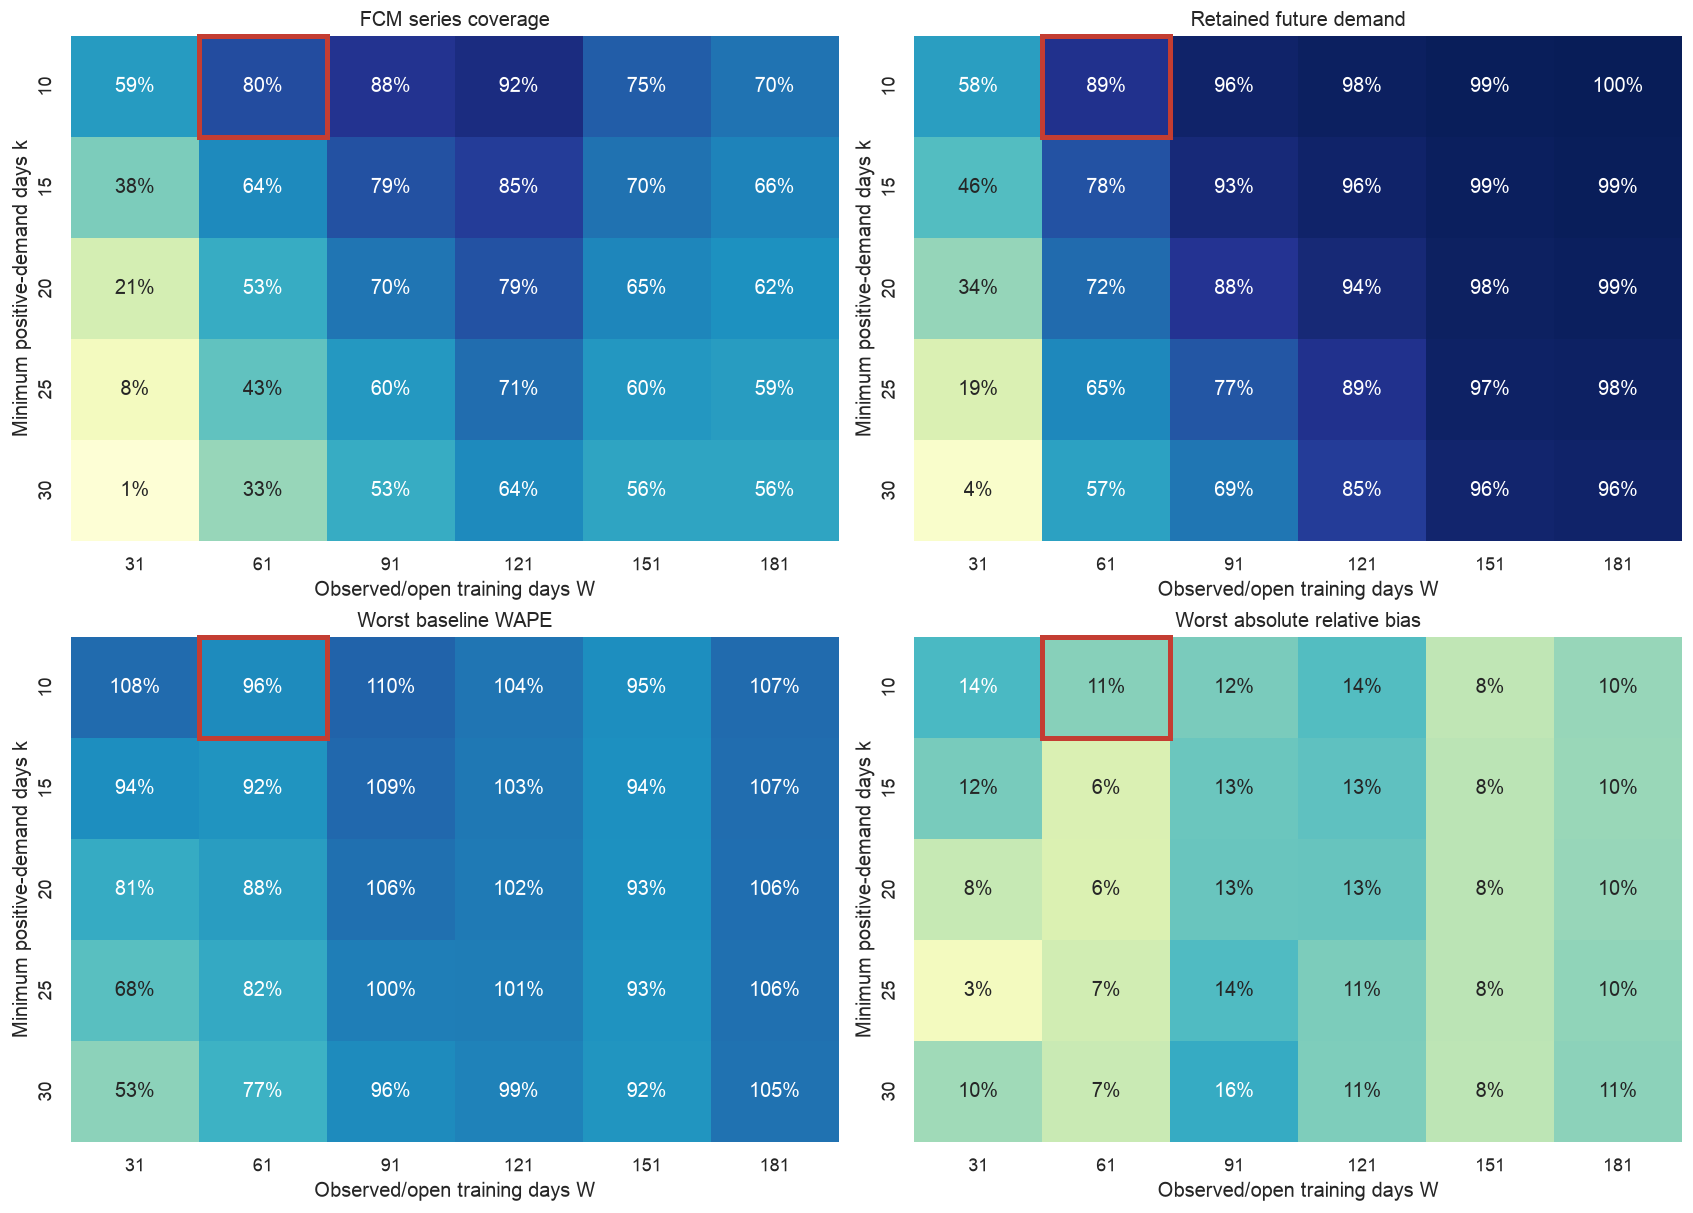

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
heatmap_specs = [
    ("series_coverage", "FCM series coverage", 0, 1, ".0%"),
    ("retained_future_demand", "Retained future demand", 0, 1, ".0%"),
    ("max_baseline_wape", "Worst baseline WAPE", 0, 1.5, ".0%"),
    ("max_abs_relative_bias", "Worst absolute relative bias", 0, 0.3, ".0%"),
]
for ax, (measure, title, vmin, vmax, fmt) in zip(axes.flat, heatmap_specs):
    matrix = fcm_results.pivot(
        index="min_demand_days", columns="window_active_days", values=measure
    )
    sns.heatmap(
        matrix, annot=True, fmt=fmt, cmap="YlGnBu", vmin=vmin, vmax=vmax,
        cbar=False, ax=ax,
    )
    selected_column = list(matrix.columns).index(SELECTED_W)
    selected_row = list(matrix.index).index(SELECTED_K)
    ax.add_patch(plt.Rectangle(
        (selected_column, selected_row), 1, 1,
        fill=False, edgecolor="#c43d32", linewidth=3, clip_on=False,
    ))
    ax.set_title(title)
    ax.set_xlabel("Observed/open training days W")
    ax.set_ylabel("Minimum positive-demand days k")
display_figure(fig)

## Why the selected pair is the first acceptable pair

The table below compares the selected pair with the same `k` at the immediately shorter candidate window, when one exists. This exposes the binding gate rather than presenting only the winning row. Per-baseline results remain visible because acceptable baseline performance must not collapse into an undocumented aggregate.

In [6]:
selected_window_index = WINDOW_CANDIDATES.index(SELECTED_W)
comparison_windows = [SELECTED_W]
if selected_window_index > 0:
    comparison_windows.insert(0, WINDOW_CANDIDATES[selected_window_index - 1])
comparison_pairs = fcm_results[
    (fcm_results["min_demand_days"] == SELECTED_K)
    & (fcm_results["window_active_days"].isin(comparison_windows))
]
display(comparison_pairs[display_columns].style.format({
    "eligible_series": "{:,.0f}",
    "series_coverage": "{:.1%}", "product_coverage": "{:.1%}",
    "store_coverage": "{:.1%}", "retained_future_demand": "{:.1%}",
    "recent_mean_wape": "{:.1%}", "same_weekday_wape": "{:.1%}",
    "occurrence_positive_quantity_wape": "{:.1%}",
    "max_baseline_wape": "{:.1%}", "max_abs_relative_bias": "{:.1%}",
}))

selected_baselines = fcm_baseline_results[
    (fcm_baseline_results["window_active_days"] == SELECTED_W)
    & (fcm_baseline_results["min_demand_days"] == SELECTED_K)
]
display(selected_baselines.style.format({
    "wape": "{:.1%}", "relative_bias": "{:+.1%}",
    "finite_forecast_share": "{:.1%}",
}))

previous_row = comparison_pairs[
    comparison_pairs["window_active_days"] < SELECTED_W
].sort_values("window_active_days").tail(1)
if not previous_row.empty:
    failed = [
        column.removeprefix("passes_").replace("_", " ")
        for column in gate_columns
        if not bool(previous_row.iloc[0][column])
    ]
    print(
        f"At W={int(previous_row.iloc[0]['window_active_days'])}, k={SELECTED_K}, "
        f"the failed gate(s) are: {', '.join(failed)}."
    )

,window_active_days,min_demand_days,eligible_series,series_coverage,product_coverage,store_coverage,retained_future_demand,recent_mean_wape,same_weekday_wape,occurrence_positive_quantity_wape,max_baseline_wape,max_abs_relative_bias,acceptable
0,31,10,"1,724",59.3%,89.7%,98.9%,58.0%,106.4%,107.6%,105.0%,107.6%,14.5%,False
5,61,10,"2,334",80.3%,82.8%,100.0%,89.0%,94.6%,96.1%,95.2%,96.1%,10.8%,True


,sourcing_group,window_active_days,min_demand_days,baseline,wape,relative_bias,finite_forecast_share
15,FCM,61,10,Recent mean (28 observations),94.6%,-6.5%,100.0%
16,FCM,61,10,Same-weekday moving average (4 occurrences),96.1%,-10.8%,100.0%
17,FCM,61,10,Occurrence x positive quantity,95.2%,-7.1%,100.0%


At W=31, k=10, the failed gate(s) are: series coverage, future demand retention.


## Decision

The result is interpreted as a minimum-information rule, not as evidence that the selected window is universally optimal. A product-store series becomes eligible for fair evaluation after meeting the selected observed/open-day and positive-demand-day requirements. The rule is calibrated on FCM, the limiting source group. Pseudo validation is deferred to `02_02_first_origin.ipynb`, where it is evaluated at the shared calendar origin using only pre-origin history. Demand-class agreement is deliberately absent from the decision.

In [7]:
print(f"Final maturity rule: (W, k) = ({SELECTED_W}, {SELECTED_K})")
print(
    f"Interpretation: at least {SELECTED_W} observed/open days and "
    f"{SELECTED_K} positive-demand days are required before a product-store "
    "series is mature for evaluation."
)

Final maturity rule: (W, k) = (61, 10)
Interpretation: at least 61 observed/open days and 10 positive-demand days are required before a product-store series is mature for evaluation.
